# NER + TF-IDF Analysis
Named Entity Recognition combined with TF-IDF entity weighting for Trump Tariff news articles.

## 1. Setup — Install & Imports

In [1]:
!pip install transformers -q

import pandas as pd
import numpy as np
from transformers import pipeline
from tqdm.auto import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from collections import defaultdict
import json
import time
import matplotlib.pyplot as plt
import seaborn as sns


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
C:\Users\ZHINI\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load NER Model

In [2]:
MODEL_NAME = "cahya/bert-base-indonesian-NER"

print(f"Loading model: {MODEL_NAME} ...")
ner = pipeline(
    "ner",
    model=MODEL_NAME,
    aggregation_strategy="first",
)

Loading model: cahya/bert-base-indonesian-NER ...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8956.32it/s]
[transformers] BertForTokenClassification LOAD REPORT from: cahya/bert-base-indonesian-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.bias   | UNEXPECTED |  | 
bert.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## 3. Load Dataset

In [3]:
CSV_PATH = "../../preprocessed/dataset_preprocessed_bert.csv"  # update path if running locally

df = pd.read_csv(CSV_PATH)

TEXT_COL = "konten_preprocessed"

df = df.dropna(subset=[TEXT_COL]).reset_index(drop=True)

print(f"Loaded {len(df):,} articles")
print(f"Columns: {df.columns.tolist()}")
df.head(3)

Loaded 999 articles
Columns: ['url', 'judul', 'konten', 'manual sentiment', 'konten_length', 'konten_preprocessed']


,url,judul,konten,manual sentiment,konten_length,konten_preprocessed
0,https://www.cnbcindonesia.com/research/2025012...,Trump Sebar Exceutive Order: Emang Semengerika...,"Jakarta, CNBC Indonesia -Amerika Serikat (AS) ...",Positive,8328,jakarta cnbc indonesia amerika serikat as seca...
1,https://www.cnbcindonesia.com/research/2025012...,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...","Jakarta, CNBC Indonesia -Nilai tukar rupiah te...",Positive,2925,jakarta cnbc indonesia nilai tukar rupiah terh...
2,https://www.cnbcindonesia.com/research/2025012...,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...","Jakarta, CNBC Indonesia-Pasar keuangan Indones...",Positive,13102,jakarta cnbc indonesia pasar keuangan indonesi...


## 4. Helper — Clean & Run NER

In [5]:
SKIP_TOKENS = {".", ",", "%", "(", ")", "-", "/", "'", '"'}
MAX_CHARS = 1500


def clean_entities(raw_entities: list) -> list:
    cleaned = []
    seen = set()

    for ent in raw_entities:
        word = ent["word"].strip().strip(".,")

        if not word or word in SKIP_TOKENS:
            continue
        if len(word) <= 1:
            continue

        label = ent["entity_group"]
        key = (word.lower(), label)

        cleaned.append({
            "word": word,
            "entity_group": label,
            "score": round(float(ent["score"]), 4),
            "start": ent.get("start"),
            "end": ent.get("end"),
            "is_duplicate": key in seen,
        })
        seen.add(key)

    return cleaned


def run_ner(text: str) -> list:
    if not isinstance(text, str) or not text.strip():
        return []
    try:
        truncated = text[:MAX_CHARS]
        raw = ner(truncated)
        return clean_entities(raw)
    except Exception as exc:
        print(f"  ⚠️  NER error: {exc}")
        return []


def display_entities(entities: list, title: str = ""):
    if title:
        print(f"\n{'='*60}")
        print(f"  {title}")
        print(f"{'='*60}")

    unique = [e for e in entities if not e["is_duplicate"]]
    print(f"{'Word':<35} | {'Label':<8} | {'Score'}")
    print("-" * 55)
    for ent in unique:
        print(f"{ent['word']:<35} | {ent['entity_group']:<8} | {ent['score']:.4f}")
    print(f"\n  → {len(unique)} unique entities found")

## 5. Single-Article Test (Sanity Check)

In [6]:
TEST_IDX = 0

test_row = df.iloc[TEST_IDX]
test_text = test_row[TEXT_COL]

print(f"Article index : {TEST_IDX}")
print(f"Title         : {test_row.get('judul', 'N/A')}")
print(f"Text length   : {len(test_text):,} chars (truncated to {MAX_CHARS} for NER)")
print(f"\nText preview  :\n{test_text[:400]}\n{'...' if len(test_text) > 400 else ''}")

test_entities = run_ner(test_text)
display_entities(test_entities, title=f"NER Results — Article {TEST_IDX}")

Article index : 0
Title         : Trump Sebar Exceutive Order: Emang Semengerikan Apa Buat Indonesia? - CNBC Indonesia
Text length   : 7,996 chars (truncated to 1500 for NER)

Text preview  :
jakarta cnbc indonesia amerika serikat as secara resmi memiliki presiden baru yang disambut positif karena agenda pro bisnis yang dibawanya presiden amerika serikat as donald trump resmi dilantik pada senin waktu as secara umum dalam pidatonya trump mengungkapkan kebijakan perdagangan proteksionis yang sebelumnya dikhawatirkan akan dilakukan secara agresif tampaknya akan diterapkan lebih terukur t
...

  NER Results — Article 0
Word                                | Label    | Score
-------------------------------------------------------
jakarta                             | ORG      | 0.4804
cnbc indonesia                      | ORG      | 0.6007
amerika serikat as                  | NOR      | 0.4990
presiden amerika serikat as         | NOR      | 0.9504
donald trump                        | PER

## 6. Full Dataset NER Run

In [7]:
all_results = []
error_indices = []

start_time = time.time()

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Running NER"):
    text = row[TEXT_COL]
    entities = run_ner(text)

    if not entities:
        error_indices.append(idx)

    for ent in entities:
        all_results.append({
            "article_idx"  : idx,
            "judul"        : row.get("judul"),
            "url"          : row.get("url"),
            "word"         : ent["word"],
            "entity_group" : ent["entity_group"],
            "score"        : ent["score"],
            "is_duplicate" : ent["is_duplicate"],
            "start"        : ent["start"],
            "end"          : ent["end"],
        })

elapsed = time.time() - start_time
print(f"\n Done in {elapsed:.1f}s")
print(f"   Articles processed       : {len(df):,}")
print(f"   Total entities           : {len(all_results):,}")
print(f"   Articles with no entities: {len(error_indices)}")

results_df = pd.DataFrame(all_results)

Running NER: 100%|██████████| 999/999 [07:07<00:00,  2.34it/s]



 Done in 427.2s
   Articles processed       : 999
   Total entities           : 28,783
   Articles with no entities: 0


## 7. TF-IDF on Extracted Entities

### Step 1: Build entity documents

In [8]:
unique_results = results_df[~results_df["is_duplicate"]]

entity_docs = (
    unique_results
    .groupby("article_idx")["word"]
    .apply(lambda x: " ".join(x.str.lower()))
    .reindex(df.index, fill_value="")   # langsung align ke df
)

print(f"Built {len(entity_docs)} entity documents")
print("Sample:", entity_docs.iloc[0])

Built 999 entity documents
Sample: jakarta cnbc indonesia amerika serikat as presiden amerika serikat as donald trump senin as trump obligasi bank sentral as the fed abc news pertama joe washington pemerintah kongres


### Step 2: TF-IDF

In [9]:
vectorizer = TfidfVectorizer(
    max_features=200,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

tfidf_matrix = vectorizer.fit_transform(entity_docs)
feature_names = vectorizer.get_feature_names_out()

print("TF-IDF shape:", tfidf_matrix.shape)

TF-IDF shape: (999, 200)


### Step 3: Mean TF-IDF

In [10]:
tfidf_df = pd.DataFrame({
    "entity": feature_names,
    "mean_tfidf": tfidf_matrix.mean(axis=0).A1
}).sort_values("mean_tfidf", ascending=False)

print(tfidf_df.head(20).to_string(index=False))

    entity  mean_tfidf
     trump    0.115784
        as    0.115206
   amerika    0.099235
 indonesia    0.091510
   serikat    0.090259
  presiden    0.085429
    donald    0.080866
     china    0.066923
   jakarta    0.065613
     april    0.055871
pemerintah    0.055583
      cnbc    0.044560
      rabu    0.039280
     eropa    0.039229
     kedua    0.037245
   menteri    0.036598
    persen    0.036506
       dua    0.035766
    kanada    0.035455
        us    0.035150


## 8. Combine NER Frequency + TF-IDF Score

In [11]:
# ── Entity frequency from NER ───────────────────────────────────────────────
entity_freq = (
    unique_results
    .groupby(["word", "entity_group"])
    .size()
    .reset_index(name="frequency")
)
entity_freq["word_lower"] = entity_freq["word"].str.lower()

# ── Merge with TF-IDF scores ─────────────────────────────────────────────────
combined_df = entity_freq.merge(
    tfidf_df.rename(columns={"entity": "word_lower"}),
    on="word_lower",
    how="left"
).fillna(0)

# ── Compute combined importance score ────────────────────────────────────────
# Normalize frequency to 0-1 scale
combined_df["freq_normalized"] = (
    combined_df["frequency"] / combined_df["frequency"].max()
)

# Combined score = average of normalized frequency + TF-IDF
# This rewards entities that are BOTH frequent AND contextually distinctive
combined_df["combined_score"] = (
    combined_df["freq_normalized"] + combined_df["mean_tfidf"]
) / 2

combined_df = combined_df.sort_values("combined_score", ascending=False)

print("Top 20 entities by Combined Score (Frequency + TF-IDF):")
print(combined_df[["word", "entity_group", "frequency", "mean_tfidf", "combined_score"]]
      .head(20)
      .to_string(index=False))

Top 20 entities by Combined Score (Frequency + TF-IDF):
                       word entity_group  frequency  mean_tfidf  combined_score
                         as          GPE        818    0.115206        0.557603
                      trump          PER        686    0.115784        0.477207
               donald trump          PER        667    0.000000        0.407702
                  indonesia          GPE        397    0.091510        0.288420
                      china          GPE        359    0.066923        0.252899
                    amerika          GPE        284    0.099235        0.223212
                    jakarta          GPE        273    0.065613        0.199677
            amerika serikat          GPE        316    0.000000        0.193154
                 pemerintah          NOR        227    0.055583        0.166545
                      april          DAT        222    0.055871        0.163632
                   presiden          NOR        145    0.085429 

## 9. Per Entity-Type Analysis

In [12]:
# ── Top entities per label type with TF-IDF scores ──────────────────────────
for label in combined_df["entity_group"].unique():
    subset = combined_df[combined_df["entity_group"] == label].head(10)
    print(f"\n{'='*60}")
    print(f"  Top 10 [{label}] entities by combined score")
    print(f"{'='*60}")
    print(subset[["word", "frequency", "mean_tfidf", "combined_score"]]
          .to_string(index=False))


  Top 10 [GPE] entities by combined score
           word  frequency  mean_tfidf  combined_score
             as        818    0.115206        0.557603
      indonesia        397    0.091510        0.288420
          china        359    0.066923        0.252899
        amerika        284    0.099235        0.223212
        jakarta        273    0.065613        0.199677
amerika serikat        316    0.000000        0.193154
         kanada        146    0.035455        0.106970
        serikat         78    0.090259        0.092807
        meksiko        124    0.031696        0.091643
          eropa        108    0.039229        0.085629

  Top 10 [PER] entities by combined score
              word  frequency  mean_tfidf  combined_score
             trump        686    0.115784        0.477207
      donald trump        667    0.000000        0.407702
            donald         77    0.080866        0.087499
                as          2    0.115206        0.058825
          presiden 

## 10. Post-Processing — Normalization & Cleaning

Based on the raw per-entity-type analysis above, we identified three categories of issues:

1. **Semantically equivalent variants** — e.g. `AS`, `Amerika`, `USA` all refer to *Amerika Serikat*; `Tiongkok`, `RRT` → *China*
2. **Label inconsistency** — e.g. `Trump` sometimes tagged as `ORG` instead of `PER` due to model noise

The normalization dictionary list below are derived directly from inspecting the raw output above.

### Step 1 — Entity Normalization

In [13]:
# ── Normalization map: surface form → canonical name ────────────────────────
# Keys are lowercase. Values are the canonical display form.
# All entries are grounded in what appeared in the raw results above.

NORMALIZATION_MAP = {
    # United States variants
    "as"            : "amerika serikat",
    "as."           : "amerika serikat",
    "usa"           : "amerika serikat",
    "u.s."          : "amerika serikat",
    "u.s.a."        : "amerika serikat",
    "us"            : "amerika serikat",
    "america"       : "amerika serikat",
    "amerika"       : "amerika serikat",
    "serikat"       : "amerika serikat",
    # China variants
    "tiongkok"      : "china",
    "rrt"           : "china",
    "prc"           : "china",
    # Indonesia variants
    "ri"            : "indonesia",
    "nkri"          : "indonesia",
    # Person name variants
    "donald trump"  : "trump",
    "trump donald"  : "trump",
    "joko widodo"   : "jokowi",
    # Institutions
    "ue"            : "uni eropa",
    "eu"            : "uni eropa",
    # Title variants
    "presiden amerika serikat as"   : "presiden as",
    "presiden amerika as"           : "presiden as",
}

def normalize_entities(df: pd.DataFrame) -> pd.DataFrame:
    """
    Apply NORMALIZATION_MAP to the 'word' column (case-insensitive).
    Returns a copy — does not modify the original results_df.
    """
    df = df.copy()
    df["word"] = df["word"].apply(
        lambda w: NORMALIZATION_MAP.get(w.lower().strip(), w)
    )
    return df

# Preview: which raw tokens will be remapped
sample_hits = results_df[
    results_df["word"].str.lower().str.strip().isin(NORMALIZATION_MAP)
][["word", "entity_group"]].drop_duplicates()

print(f"Raw tokens that will be normalized: {len(sample_hits)}")
print(sample_hits.to_string(index=False))


Raw tokens that will be normalized: 42
                       word entity_group
presiden amerika serikat as          NOR
               donald trump          PER
                         as          GPE
                    amerika          GPE
                         us          LAW
                         ri          GPE
                         ri          ORG
                         as          ORG
                         as          PRD
                   tiongkok          GPE
                    america          GPE
                         us          MON
                         us          ORG
                         ue          GPE
                         ue          NOR
                    serikat          GPE
                    amerika          NOR
                         us          PRD
                         ue          ORG
                    serikat          NOR
                    serikat          ORG
                    amerika          MON
                  

### Step 2 — Label Consistency

In [14]:
# ── Manual label overrides for entities with known correct labels ────────────
# These were identified from the per-entity-type table above where the same
# surface form appeared under multiple labels.

LABEL_OVERRIDES = {
    "trump"           : "PER",
    "biden"           : "PER",
    "prabowo"         : "PER",
    "jokowi"          : "PER",
    "xi jinping"      : "PER",
    "china"           : "GPE",
    "indonesia"       : "GPE",
    "amerika serikat" : "GPE",
    "wto"             : "ORG",
    "imf"             : "ORG",
    "pbb"             : "ORG",
    "uni eropa"       : "ORG",
}

def fix_labels(df: pd.DataFrame) -> pd.DataFrame:
    """
    Two-step label correction:
      1. Dominant-label: for each entity word, find the most frequent label
         assigned by the model across all articles — use that as the default.
      2. Manual override: apply LABEL_OVERRIDES on top for known-noisy cases.
    """
    df = df.copy()
    df["word_lower"] = df["word"].str.lower().str.strip()

    # Step 1 — dominant label from data
    dominant = (
        df.groupby(["word_lower", "entity_group"])
        .size()
        .reset_index(name="n")
        .sort_values("n", ascending=False)
        .drop_duplicates(subset="word_lower", keep="first")
        .set_index("word_lower")["entity_group"]
    )

    # Step 2 — apply, with manual override winning
    def resolve(row):
        w = row["word_lower"]
        if w in LABEL_OVERRIDES:
            return LABEL_OVERRIDES[w]
        return dominant.get(w, row["entity_group"])

    original_labels = df["entity_group"].copy()
    df["entity_group"] = df.apply(resolve, axis=1)

    changed = (original_labels != df["entity_group"]).sum()
    print(f"Labels corrected: {changed:,} rows")
    df.drop(columns=["word_lower"], inplace=True)
    return df

# Preview label conflicts in raw data (same word, multiple labels)
label_conflicts = (
    results_df[~results_df["is_duplicate"]]
    .groupby("word")["entity_group"]
    .nunique()
)
conflicts = label_conflicts[label_conflicts > 1].index.tolist()
print(f"Entities with >1 label in raw data: {len(conflicts)}")
print(results_df[results_df["word"].isin(conflicts[:10])]
      [["word", "entity_group"]]
      .drop_duplicates()
      .sort_values("word")
      .to_string(index=False))


Entities with >1 label in raw data: 556
         word entity_group
         aceh          LOC
         aceh          GPE
          act          LAW
          act          ORG
         adil          LAW
         adil          PER
          afp          ORG
          afp          NOR
      agustus          DAT
      agustus          PRD
      agustus          LAW
           ai          ORG
           ai          PRD
           ai          PER
air force one          EVT
air force one          NOR
    airlangga          PER
    airlangga          NOR
    airlangga          ORG
    airlangga          PRD
           al          ORG
           al          NOR
   al jazeera          NOR
   al jazeera          ORG


### Step 3 — Apply Post-Processing Pipeline

In [15]:
# Apply all three steps to produce results_df_clean.
# results_df (raw) is preserved for comparison below.

results_df_clean = results_df.copy()
results_df_clean = normalize_entities(results_df_clean)
results_df_clean = fix_labels(results_df_clean)

print(f"\nRaw rows    : {len(results_df):,}")
print(f"Cleaned rows: {len(results_df_clean):,}")


Labels corrected: 2,443 rows

Raw rows    : 28,783
Cleaned rows: 28,783


### Step 4 — Re-run TF-IDF & Scoring on Cleaned Data

In [16]:
# Rebuild TF-IDF using the cleaned entity set.
unique_clean = results_df_clean[~results_df_clean["is_duplicate"]]

entity_docs_clean = (
    unique_clean
    .groupby("article_idx")["word"]
    .apply(lambda x: " ".join(x.str.lower()))
    .reindex(df.index, fill_value="")
)

vectorizer_clean = TfidfVectorizer(
    max_features=200,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)
tfidf_matrix_clean   = vectorizer_clean.fit_transform(entity_docs_clean)
feature_names_clean  = vectorizer_clean.get_feature_names_out()

tfidf_df_clean = pd.DataFrame({
    "entity"     : feature_names_clean,
    "mean_tfidf" : tfidf_matrix_clean.mean(axis=0).A1
}).sort_values("mean_tfidf", ascending=False)

# Frequency + combined score
entity_freq_clean = (
    unique_clean
    .groupby(["word", "entity_group"])
    .size()
    .reset_index(name="frequency")
)
entity_freq_clean["word_lower"] = entity_freq_clean["word"].str.lower()

combined_df_clean = entity_freq_clean.merge(
    tfidf_df_clean.rename(columns={"entity": "word_lower"}),
    on="word_lower",
    how="left"
).fillna(0)

combined_df_clean["freq_normalized"] = (
    combined_df_clean["frequency"] / combined_df_clean["frequency"].max()
)
combined_df_clean["combined_score"] = (
    combined_df_clean["freq_normalized"] + combined_df_clean["mean_tfidf"]
) / 2

combined_df_clean = combined_df_clean.sort_values("combined_score", ascending=False)

print("Top 20 entities (cleaned) by Combined Score:")
print(combined_df_clean[["word", "entity_group", "frequency", "mean_tfidf", "combined_score"]]
      .head(20)
      .round(4)
      .to_string(index=False))


Top 20 entities (cleaned) by Combined Score:
           word entity_group  frequency  mean_tfidf  combined_score
amerika serikat          GPE       1727      0.0000          0.5000
          trump          PER       1440      0.1158          0.4748
      indonesia          GPE        557      0.0951          0.2088
          china          GPE        445      0.0717          0.1647
        jakarta          GPE        342      0.0656          0.1318
    presiden as          NOR        400      0.0000          0.1158
          april          DAT        246      0.0557          0.0991
     pemerintah          NOR        228      0.0554          0.0937
       presiden          NOR        169      0.0855          0.0917
          kedua          CRD        181      0.0372          0.0710
         persen          PRC        169      0.0364          0.0671
           rabu          DAT        153      0.0394          0.0640
            dua          CRD        151      0.0357          0.0616
   

### Step 6 — Before vs After Comparison

In [17]:
# ── Side-by-side: Top 15 raw vs cleaned ─────────────────────────────────────

def make_display_table(df, n=15):
    return (
        df.head(n)
        .reset_index(drop=True)
        [["word", "entity_group", "frequency", "mean_tfidf", "combined_score"]]
        .rename(columns={
            "word"          : "Entity",
            "entity_group"  : "Label",
            "frequency"     : "Freq",
            "mean_tfidf"    : "TF-IDF",
            "combined_score": "Score",
        })
        .round({"TF-IDF": 4, "Score": 4})
        .assign(Rank=range(1, n + 1))
        .set_index("Rank")
    )

raw_top    = make_display_table(combined_df)
clean_top  = make_display_table(combined_df_clean)

print("=" * 55)
print("  RAW (before post-processing)")
print("=" * 55)
display(raw_top)

print("\n" + "=" * 55)
print("  CLEANED (after normalization + label fix)")
print("=" * 55)
display(clean_top)


  RAW (before post-processing)


,Entity,Label,Freq,TF-IDF,Score
Rank,,,,,
1,as,GPE,818,0.1152,0.5576
2,trump,PER,686,0.1158,0.4772
3,donald trump,PER,667,0.0000,0.4077
4,indonesia,GPE,397,0.0915,0.2884
5,china,GPE,359,0.0669,0.2529
6,amerika,GPE,284,0.0992,0.2232
7,jakarta,GPE,273,0.0656,0.1997
8,amerika serikat,GPE,316,0.0000,0.1932
9,pemerintah,NOR,227,0.0556,0.1665



  CLEANED (after normalization + label fix)


,Entity,Label,Freq,TF-IDF,Score
Rank,,,,,
1,amerika serikat,GPE,1727,0.0000,0.5000
2,trump,PER,1440,0.1158,0.4748
3,indonesia,GPE,557,0.0951,0.2088
4,china,GPE,445,0.0717,0.1647
5,jakarta,GPE,342,0.0656,0.1318
6,presiden as,NOR,400,0.0000,0.1158
7,april,DAT,246,0.0557,0.0991
8,pemerintah,NOR,228,0.0554,0.0937
9,presiden,NOR,169,0.0855,0.0917


### Step 7 — Per Entity-Type Analysis (Cleaned)

In [18]:
for label in sorted(combined_df_clean["entity_group"].unique()):
    subset = combined_df_clean[combined_df_clean["entity_group"] == label].head(10)
    print(f"\n{'='*60}")
    print(f"  Top 10 [{label}] — after post-processing")
    print(f"{'='*60}")
    print(subset[["word", "frequency", "mean_tfidf", "combined_score"]]
          .round(4)
          .to_string(index=False))



  Top 10 [CRD] — after post-processing
    word  frequency  mean_tfidf  combined_score
   kedua        181      0.0372          0.0710
     dua        151      0.0357          0.0616
    satu        125      0.0299          0.0511
    tiga         81      0.0251          0.0360
   empat         28      0.0108          0.0135
    lima         26      0.0099          0.0125
 delapan         12      0.0000          0.0035
    enam          8      0.0000          0.0023
setengah          7      0.0000          0.0020
   tujuh          6      0.0000          0.0017

  Top 10 [DAT] — after post-processing
    word  frequency  mean_tfidf  combined_score
   april        246      0.0557          0.0991
    rabu        153      0.0394          0.0640
  selasa        115      0.0318          0.0492
   senin        119      0.0290          0.0490
   kamis        114      0.0312          0.0486
   jumat         92      0.0233          0.0383
 januari         79      0.0221          0.0339
   sabtu

# 10. Visualization — Raw vs Cleaned

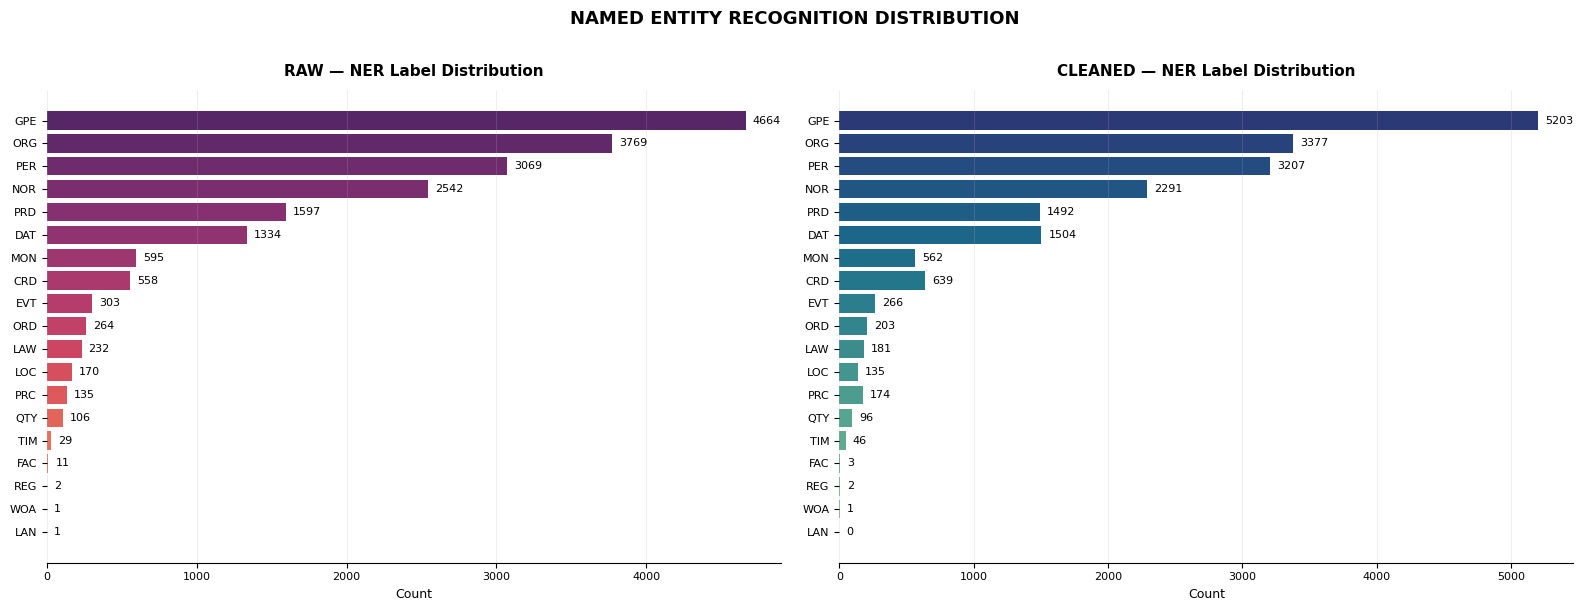

In [19]:
# Label distribution: Raw vs Cleaned
label_counts_raw = (
    results_df[~results_df["is_duplicate"]]["entity_group"]
    .value_counts()
)

has_clean = "results_df_clean" in dir() and results_df_clean is not None

if has_clean:
    label_counts_clean = (
        results_df_clean[~results_df_clean["is_duplicate"]]["entity_group"]
        .value_counts()
    )
    # Align both on the same label set
    all_labels = label_counts_raw.index.union(label_counts_clean.index)
    label_counts_raw   = label_counts_raw.reindex(all_labels, fill_value=0)
    label_counts_clean = label_counts_clean.reindex(all_labels, fill_value=0)
    # Sort by raw count descending
    order = label_counts_raw.sort_values().index

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    plt.style.use("ggplot")

    for ax, counts, title, palette in zip(
        axes,
        [label_counts_raw.loc[order], label_counts_clean.loc[order]],
        ["RAW — NER Label Distribution", "CLEANED — NER Label Distribution"],
        ["flare", "crest"],
    ):
        colors = sns.color_palette(palette, len(counts))
        ax.barh(counts.index, counts.values, color=colors)
        ax.set_title(title, fontsize=11, weight="bold", pad=10)
        ax.set_xlabel("Count", fontsize=9)
        ax.set_ylabel("")
        ax.grid(axis="x", linestyle="-", linewidth=0.5, alpha=0.3)
        ax.grid(axis="y", visible=False)
        for spine in ["top", "right", "left"]:
            ax.spines[spine].set_visible(False)
        ax.tick_params(axis="both", labelsize=8)
        for i, v in enumerate(counts.values):
            ax.text(v + max(counts.values) * 0.01, i,
                    f"{v}", va="center", fontsize=8)

    plt.suptitle("NAMED ENTITY RECOGNITION DISTRIBUTION",
                 fontsize=13, weight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

else:
    # Post-processing not yet run — show raw only (original behaviour)
    plt.style.use("ggplot")
    fig, ax = plt.subplots(figsize=(12, 6))
    colors = sns.color_palette("flare", len(label_counts_raw))
    order  = label_counts_raw.sort_values().index
    counts = label_counts_raw.loc[order]

    ax.barh(counts.index, counts.values, color=colors)
    ax.set_title("NAMED ENTITY RECOGNITION DISTRIBUTION",
                 fontsize=12, weight="bold", pad=12)
    ax.set_xlabel("Count", fontsize=9)
    ax.set_ylabel("")
    ax.grid(axis="x", linestyle="-", linewidth=0.5, alpha=0.3)
    ax.grid(axis="y", visible=False)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.tick_params(axis="both", labelsize=8)
    for i, v in enumerate(counts.values):
        ax.text(v + max(counts.values) * 0.01, i,
                f"{v}", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()


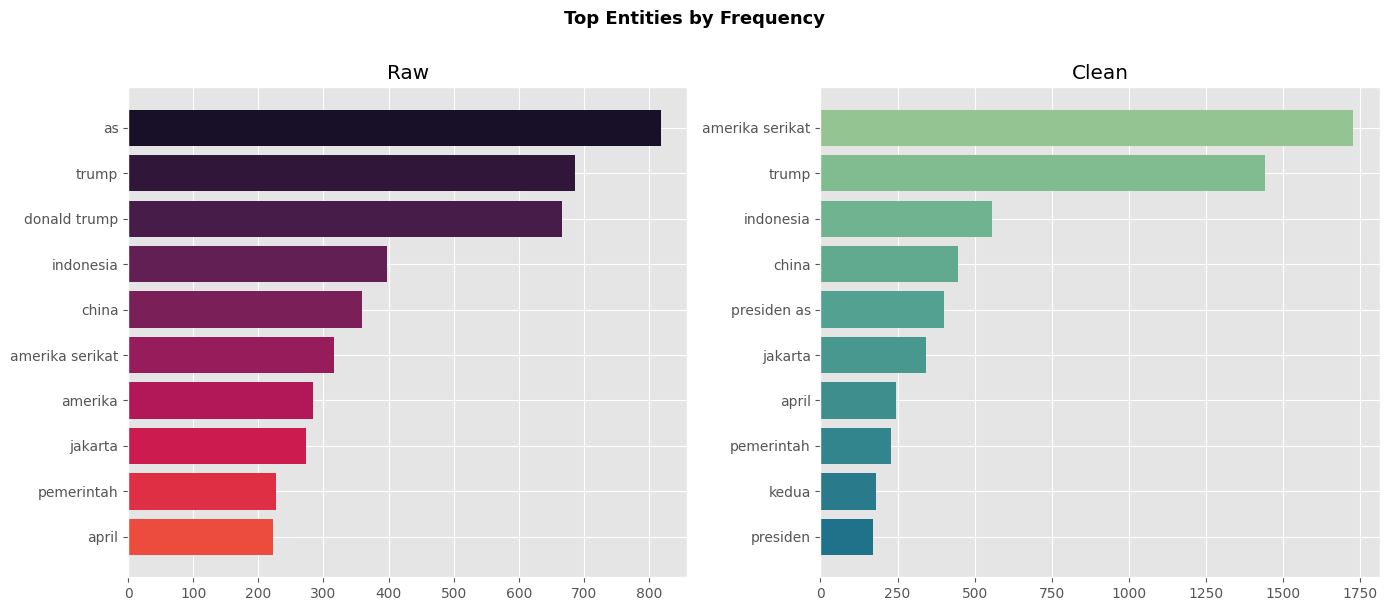

In [20]:
# Top Entities by Frequency
TOP_N = 10

# Prepare
raw_plot = raw_top.reset_index()
clean_plot = clean_top.reset_index()

# Sort by Frequency
raw_freq = raw_plot.sort_values("Freq", ascending=False).head(TOP_N)
clean_freq = clean_plot.sort_values("Freq", ascending=False).head(TOP_N)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# RAW
axes[0].barh(raw_freq["Entity"], raw_freq["Freq"], color=sns.color_palette("rocket", len(raw_plot)))
axes[0].set_title("Raw")
axes[0].invert_yaxis()

# CLEAN
axes[1].barh(clean_freq["Entity"], clean_freq["Freq"], color=sns.color_palette("crest", len(raw_plot)))
axes[1].set_title("Clean")
axes[1].invert_yaxis()

plt.suptitle("Top Entities by Frequency",
             fontsize=13, weight="bold", y=1.01)
plt.tight_layout()
plt.show()

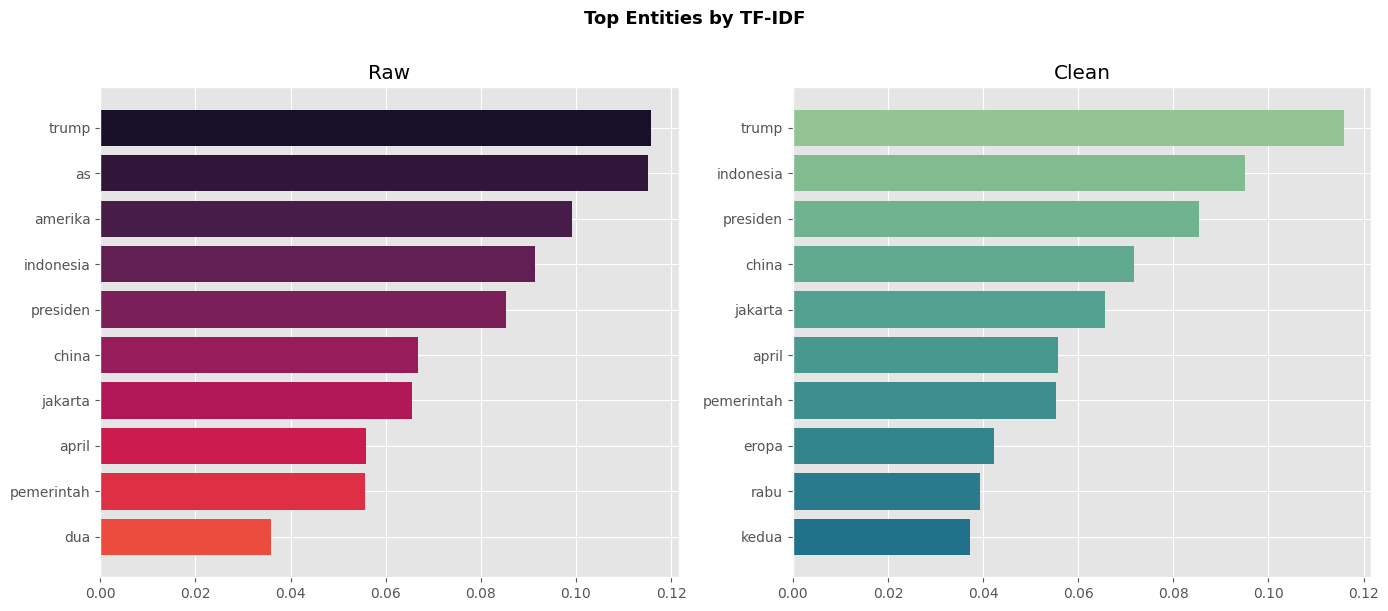

In [21]:
# Top Entities by TF-IDF
TOP_N = 10

# Prepare
raw_plot = raw_top.reset_index()
clean_plot = clean_top.reset_index()

# Sort by TF-IDF
raw_tfidf = raw_plot.sort_values("TF-IDF", ascending=False).head(TOP_N)
clean_tfidf = clean_plot.sort_values("TF-IDF", ascending=False).head(TOP_N)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# RAW
axes[0].barh(raw_tfidf["Entity"], raw_tfidf["TF-IDF"], color=sns.color_palette("rocket", len(raw_plot)))
axes[0].set_title("Raw")
axes[0].invert_yaxis()

# CLEAN
axes[1].barh(clean_tfidf["Entity"], clean_tfidf["TF-IDF"], color=sns.color_palette("crest", len(raw_plot)))
axes[1].set_title("Clean")
axes[1].invert_yaxis()

plt.suptitle("Top Entities by TF-IDF",
             fontsize=13, weight="bold", y=1.01)
plt.tight_layout()
plt.show()

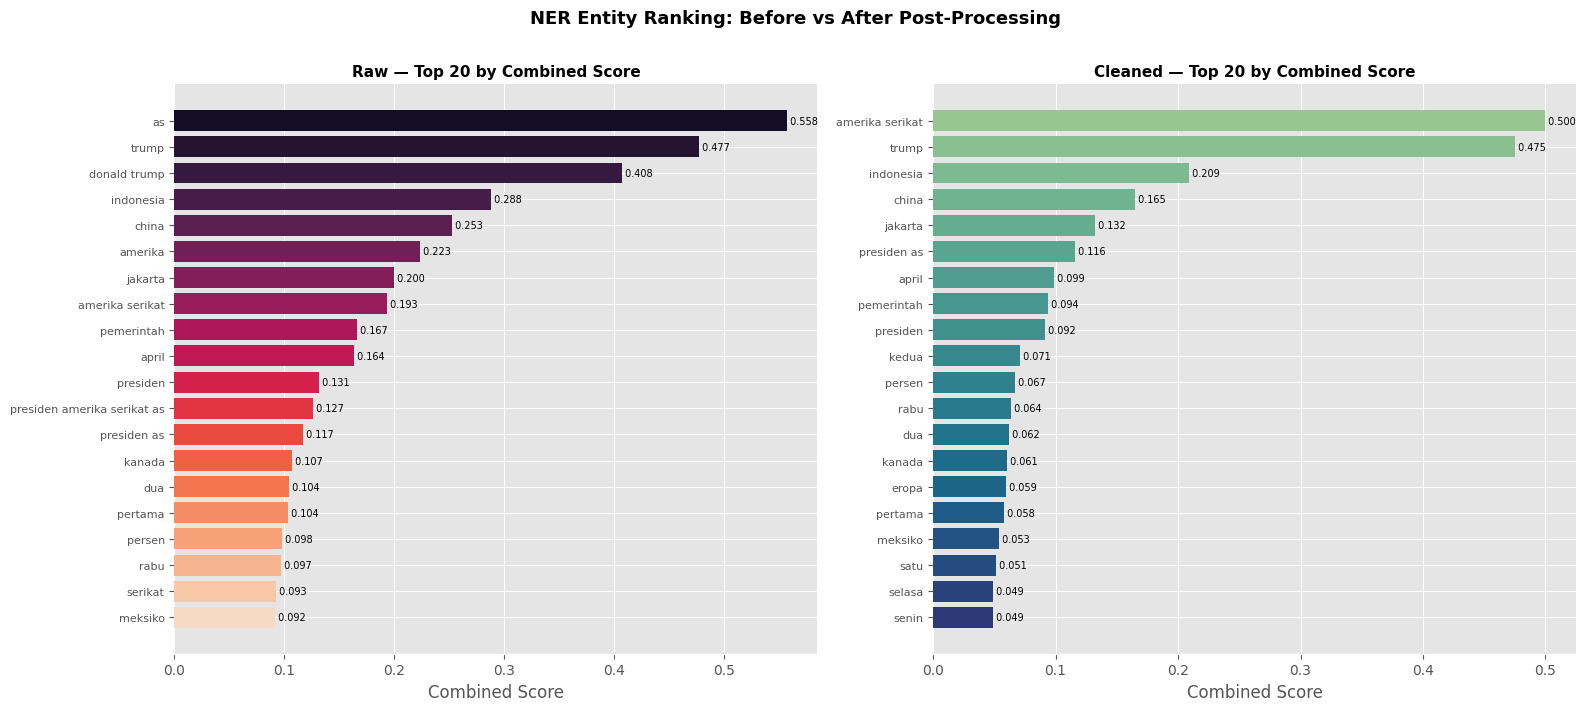

In [22]:
# Entity Ranking by Combined Score
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, df_plot, title, palette in zip(
    axes,
    [combined_df.head(20), combined_df_clean.head(20)],
    ["Raw — Top 20 by Combined Score", "Cleaned — Top 20 by Combined Score"],
    ["rocket", "crest"],
):
    colors = sns.color_palette(palette, len(df_plot))
    ax.barh(df_plot["word"][::-1], df_plot["combined_score"][::-1], color=colors[::-1])
    ax.set_title(title, fontsize=11, weight="bold")
    ax.set_xlabel("Combined Score")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.tick_params(axis="y", labelsize=8)

    for i, (_, row) in enumerate(df_plot[::-1].iterrows()):
        ax.text(row["combined_score"], i, f" {row['combined_score']:.3f}",
                va="center", fontsize=7)

plt.suptitle("NER Entity Ranking: Before vs After Post-Processing",
             fontsize=13, weight="bold", y=1.01)
plt.tight_layout()
plt.show()


## 11. Export Results

In [24]:
import os

OUTPUT_DIR = "../../outputs/ner"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Export 1: Combined NER + TF-IDF scores ───────────────────────────────────
COMBINED_CSV_RAW = f"{OUTPUT_DIR}/ner_tfidf_combined_raw.csv"
combined_df.to_csv(COMBINED_CSV_RAW, index=False)
print(f"Combined results raw saved → {COMBINED_CSV_RAW}")

COMBINED_CSV_CLEAN = f"{OUTPUT_DIR}/ner_tfidf_combined_clean.csv"
combined_df_clean.to_csv(COMBINED_CSV_CLEAN, index=False)
print(f"Combined results clean saved → {COMBINED_CSV_CLEAN}")

# ── Export 2a: Per-article summary ─────────────────────────────────
unique_df = results_df[~results_df["is_duplicate"]].copy()

unique_df["entity_record"] = unique_df.apply(
    lambda r: {
        "word": r["word"],
        "entity_group": r["entity_group"],
        "score": round(float(r["score"]), 4)
    },
    axis=1
)

summary_df = (
    unique_df
    .groupby(["article_idx", "judul", "url"], as_index=False, dropna=False)["entity_record"]
    .agg(list)
    .rename(columns={"entity_record": "entities"})
)

summary_df["entity_count"] = summary_df["entities"].apply(len)
summary_df["entities_json"] = summary_df["entities"].apply(json.dumps)

SUMMARY_CSV = f"{OUTPUT_DIR}/ner_results_summary_raw.csv"
summary_df.drop(columns=["entities"]).to_csv(SUMMARY_CSV, index=False)
print(f"Summary saved → {SUMMARY_CSV}  ({len(summary_df):,} articles)")

# ── Export 2b: Per-article summary (CLEAN) ─────────────────────────────
unique_df_clean = results_df_clean[~results_df_clean["is_duplicate"]].copy()

unique_df_clean["entity_record"] = unique_df_clean.apply(
    lambda r: {
        "word": r["word"],
        "entity_group": r["entity_group"],
        "score": round(float(r["score"]), 4)
    },
    axis=1
)

summary_df_clean = (
    unique_df_clean
    .groupby(["article_idx", "judul", "url"], as_index=False, dropna=False)["entity_record"]
    .agg(list)
    .rename(columns={"entity_record": "entities"})
)

summary_df_clean["entity_count"] = summary_df_clean["entities"].apply(len)
summary_df_clean["entities_json"] = summary_df_clean["entities"].apply(json.dumps)

SUMMARY_CSV_CLEAN = f"{OUTPUT_DIR}/ner_results_summary_clean.csv"
summary_df_clean.drop(columns=["entities"]).to_csv(SUMMARY_CSV_CLEAN, index=False)

print(f"Summary (clean) saved → {SUMMARY_CSV_CLEAN}  ({len(summary_df_clean):,} articles)")

# ── Export 3: TF-IDF scores only ─────────────────────────────────────────────
TFIDF_CSV_RAW = f"{OUTPUT_DIR}/entity_tfidf_scores_raw.csv"
tfidf_df.to_csv(TFIDF_CSV_RAW, index=False)
print(f"TF-IDF raw scores saved → {TFIDF_CSV_RAW}")

TFIDF_CSV_CLEAN = f"{OUTPUT_DIR}/entity_tfidf_scores_clean.csv"
tfidf_df_clean.to_csv(TFIDF_CSV_CLEAN, index=False)
print(f"TF-IDF clean scores saved → {TFIDF_CSV_CLEAN}")

print("\n✅ All exports complete")

# ── Preview ─────────────────────────────────────────────────────────────
print("\n--- RAW SUMMARY PREVIEW ---")
display(summary_df.drop(columns=["entities_json"]).head(5))

print("\n--- CLEAN SUMMARY PREVIEW ---")
display(summary_df_clean.drop(columns=["entities_json"]).head(5))

Combined results raw saved → ../../outputs/ner/ner_tfidf_combined_raw.csv
Combined results clean saved → ../../outputs/ner/ner_tfidf_combined_clean.csv
Summary saved → ../../outputs/ner/ner_results_summary_raw.csv  (999 articles)
Summary (clean) saved → ../../outputs/ner/ner_results_summary_clean.csv  (999 articles)
TF-IDF raw scores saved → ../../outputs/ner/entity_tfidf_scores_raw.csv
TF-IDF clean scores saved → ../../outputs/ner/entity_tfidf_scores_clean.csv

✅ All exports complete

--- RAW SUMMARY PREVIEW ---


,article_idx,judul,url,entities,entity_count
0,0,Trump Sebar Exceutive Order: Emang Semengerika...,https://www.cnbcindonesia.com/research/2025012...,"[{'word': 'jakarta', 'entity_group': 'ORG', 's...",17
1,1,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...",https://www.cnbcindonesia.com/research/2025012...,"[{'word': 'jakarta', 'entity_group': 'GPE', 's...",21
2,2,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...",https://www.cnbcindonesia.com/research/2025012...,"[{'word': 'jakarta', 'entity_group': 'GPE', 's...",20
3,3,"IHSG Merah Lagi, Begini Penjelasan dari Analis...",https://www.cnbcindonesia.com/research/2025030...,"[{'word': 'jakarta', 'entity_group': 'ORG', 's...",25
4,4,Bernstein: Bitcoin Bisa Naik 2x Lipat! Target ...,https://indodax.com/academy/bitcoin-200k-predi...,"[{'word': 'btc', 'entity_group': 'PRD', 'score...",12



--- CLEAN SUMMARY PREVIEW ---


,article_idx,judul,url,entities,entity_count
0,0,Trump Sebar Exceutive Order: Emang Semengerika...,https://www.cnbcindonesia.com/research/2025012...,"[{'word': 'jakarta', 'entity_group': 'GPE', 's...",17
1,1,"Alasan Rupiah 'Berpesta' di Pelantikan Trump, ...",https://www.cnbcindonesia.com/research/2025012...,"[{'word': 'jakarta', 'entity_group': 'GPE', 's...",21
2,2,"Trump Beri Kabar Baik, Saatnya Menunggu Dolar ...",https://www.cnbcindonesia.com/research/2025012...,"[{'word': 'jakarta', 'entity_group': 'GPE', 's...",20
3,3,"IHSG Merah Lagi, Begini Penjelasan dari Analis...",https://www.cnbcindonesia.com/research/2025030...,"[{'word': 'jakarta', 'entity_group': 'GPE', 's...",25
4,4,Bernstein: Bitcoin Bisa Naik 2x Lipat! Target ...,https://indodax.com/academy/bitcoin-200k-predi...,"[{'word': 'btc', 'entity_group': 'PRD', 'score...",12
